# Modeling의 목표
- RandomForest 모델 실험
- XGBoost 모델 실험
- RF, XG 모델 각각의 교차검증 진행

In [1]:
# 기본라이브러리 + 데이터 불러오기
import pandas as pd
import numpy as np

train = pd.read_csv('./data/Finaldata/train_final.csv')
test = pd.read_csv('./data/Finaldata/test_final.csv')


# 안정적인 전체 실행을 위한 기본값. 환경이 충분하면 -1 또는 4로 변경 가능
N_JOBS = 1

### 데이터 분리

In [2]:
# 모델링용 데이터 분리
# AccidentId는 추적용 식별자이므로 모델 입력에서 제외
drop_cols = ['Gravity', 'AccidentId']
X_train = train.drop(columns=drop_cols)
y_train = train['Gravity'].copy()

X_test = test.drop(columns=drop_cols)
y_test = test['Gravity'].copy()

assert 'AccidentId' not in X_train.columns
assert X_train.columns.tolist() == X_test.columns.tolist()
print(f"학습 데이터: {X_train.shape}, 평가 데이터: {X_test.shape}")


학습 데이터: (38256, 192), 평가 데이터: (9565, 192)


### 기준 모델

- 다수 클래스만 예측해도 높은 정확도가 나오는 문제이므로 `DummyClassifier`를 기준선으로 사용한다. 
- 이후 모델은 Accuracy보다 양성 클래스의 Recall·F1·F2와 확률 순위 성능인 ROC-AUC·PR-AUC를 중심으로 비교한다.


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, fbeta_score

baseline_scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'f2': make_scorer(fbeta_score, beta=2),
    'roc_auc': 'roc_auc',
    'AP': 'average_precision',
}

dummy = DummyClassifier(strategy='prior')
dummy_cv = cross_validate(dummy, X_train, y_train, cv=5, scoring=baseline_scoring)
print('[DummyClassifier 기준선]')
for metric in baseline_scoring:
    print(f"{metric}: {dummy_cv[f'test_{metric}'].mean():.4f}")


[DummyClassifier 기준선]
accuracy: 0.9444
recall: 0.0000
f1: 0.0000
f2: 0.0000
roc_auc: 0.5000
AP: 0.0556


#### 기준선 모델 평가

- 피처를 활용하지 않고 다수 클래스를 예측하는 DummyClassifier를 기준선으로 설정하여 5겹 교차검증을 수행

정확도는 94.44%였으나, 모든 사고를 NonLethal로 예측하여 Lethal Recall은 0%로 나타났다.     
이를 통해 클래스 불균형 상황에서는 정확도만으로 치명적 사고 탐지 성능을 평가하기 어렵다는 점을 확인

### RandomForest 교차검증

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

rf = RandomForestClassifier(n_estimators=300,
                            random_state=15,         # 모델의 성능 비교를 위해 사용 
                            n_jobs=N_JOBS,
                            class_weight='balanced') # 타깃값 불균형으로 balanced적용 

skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=15)


In [5]:
# 평가지표: 불균형 분류이므로 F1, Recall, F2, PR-AUC를 함께 확인
from sklearn.metrics import make_scorer, fbeta_score

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'f2': make_scorer(fbeta_score, beta=2),
    'roc_auc': 'roc_auc',
    'AP': 'average_precision',
}

rf_cv = cross_validate(
    rf, X_train, y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=N_JOBS
)


In [6]:
# 평균 점수 확인
for metric in scoring :
    print(f"{metric}: {rf_cv[f'test_{metric}'].mean():.4f}") # 소수점 4자리까지만 표기


accuracy: 0.9421
precision: 0.4107
recall: 0.0940
f1: 0.1529
f2: 0.1111
roc_auc: 0.8206
AP: 0.2364


- precision : 0.3997 , recall : 0.0912 값으로 양성 클래스를 거의 찾아내지 못하였다.
- 이를 개선하기 위해 predict_proba로 확률을 뽑은 뒤 precision-recall curve를 그려서 임계값 threshold를 조정해본다.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# OOF(out-of-fold) 예측 확률
y_proba = cross_val_predict(rf, X_train, y_train,
                             cv=skf,
                             method='predict_proba',
                             n_jobs=N_JOBS)[:, 1]  # 양성 클래스 확률

# precision-recall curve로 threshold별 지표 계산
precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba)

# threshold별 F1 계산 - 마지막 값 threshold가 없어 제외
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# 4. F1이 최대인 지점 찾기
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"최적 threshold: {best_threshold:.4f}")
print(f"해당 지점 - precision: {precisions[best_idx]:.4f}, "
      f"recall: {recalls[best_idx]:.4f}, f1: {f1_scores[best_idx]:.4f}")


최적 threshold: 0.2967
해당 지점 - precision: 0.2540, recall: 0.4070, f1: 0.3128


In [8]:
y_pred_adjusted = (y_proba >= best_threshold).astype(int)
print("\n--최적 threshold 적용--")
print(classification_report(y_train, y_pred_adjusted))


--최적 threshold 적용--
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     36128
           1       0.25      0.41      0.31      2128

    accuracy                           0.90     38256
   macro avg       0.61      0.67      0.63     38256
weighted avg       0.92      0.90      0.91     38256



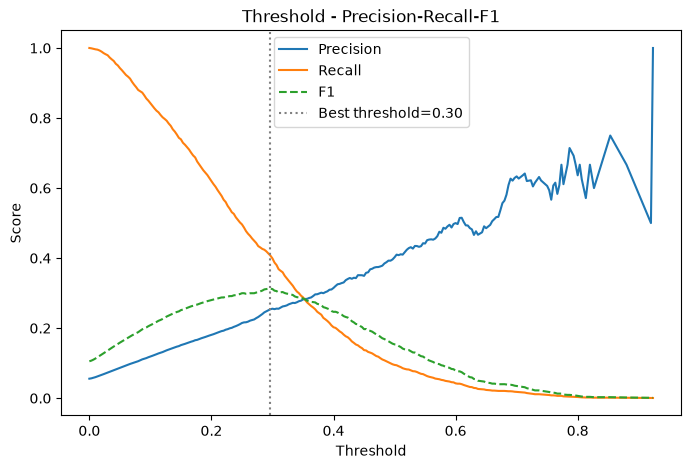

In [9]:
# precision-recall trade-off 시각화
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores, label='F1', linestyle='--')
plt.axvline(best_threshold, color='gray', linestyle=':', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Threshold - Precision-Recall-F1')
plt.show()


- threshold 0.5 이상 구간에서 양성 예측 수 자체가 적어져 precision이 급격이 요동치는 패턴이 발생한다.
- 이 구간의 변동은 모델 성능 향상이 아닌 표본 수 부족에 따른 노이즈로 판단하였다.
- 또한 기본 임계값 0.5는 데이터 불균형 상황에서 소수 클래스를 거의 예측하지 못해 recall이 지나치게 낮은 문제가 있었다
- precision과 recall을 모두 고려하는 F1 기준으로 threshold를 재탐색해 두 지표의 균형을 맞추고자 최적의 임계값은 0.28을 기준으로 F1을 최대화 하였다.

In [10]:
# 모델 학습
rf.fit(X_train, y_train);

In [11]:
# 최종 모델 데이터 예측
y_test_proba_rf = rf.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= best_threshold).astype(int)

In [12]:
from sklearn.metrics import (
    classification_report, f1_score, fbeta_score,
    recall_score, precision_score, roc_auc_score, average_precision_score,
    confusion_matrix
)

def evaluate_heldout(y_true, y_proba, threshold, model_name):
    y_pred = (y_proba >= threshold).astype(int)
    result = {
        'model': model_name,
        'threshold': threshold,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'f2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'AP': average_precision_score(y_true, y_proba),
    }
    print(f"[{model_name}, threshold={threshold:.4f}]")
    print(classification_report(y_true, y_pred, zero_division=0))
    print('Confusion matrix')
    print(confusion_matrix(y_true, y_pred))
    display(pd.DataFrame([result]).round(4))
    return result

model_results = []

In [13]:
rf_result = evaluate_heldout(
    y_test, y_test_proba_rf, best_threshold, 'RandomForest 기본'
)
model_results.append(rf_result)

[RandomForest 기본, threshold=0.2967]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      9033
           1       0.25      0.39      0.30       532

    accuracy                           0.90      9565
   macro avg       0.61      0.66      0.62      9565
weighted avg       0.92      0.90      0.91      9565

Confusion matrix
[[8401  632]
 [ 324  208]]


,model,threshold,precision,recall,f1,f2,roc_auc,AP
0,RandomForest 기본,0.2967,0.2476,0.391,0.3032,0.3504,0.8174,0.2254


### RandomForest 실험 결과
- 전체 accuracy는 0.89로 높게 보이지만 이것은 다수의 클래스가 음성(0)인 비율로 비중이 커서 일어나는 착시이다.
- 양성 클래스를 기준으로 살펴보면 precision이 매우 낮고 양성으로 예측한 것 중 실제 양성 비율이 낮다는것을 알 수 있다.
- 또한 양성 클래스 recall도 0.45로 실제 양성 사례의 절반도 잡아내지 못한것을 확인 할 수 있었다.
- 종합적으로 RandomForest는 양성 클래스를 안정적으로 찾아내는 데 한계가 있다고 판단된다
- 이에 따라 트리 기반의 다른 알고리즘인 XGBoost로 동일한 조건에서 성능을 비교해보고자 한다

### XGBoost 교차검증

In [14]:
from xgboost import XGBClassifier

# 클래스 불균형 비율 계산 (scale_pos_weight)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    random_state=15,
    n_jobs=N_JOBS,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb_cv = cross_validate(xgb,
                        X_train,
                        y_train,
                        cv=skf,
                        scoring=scoring,
                        n_jobs=N_JOBS)

print("[XGBoost 교차검증 결과]")
for metric in scoring:
    print(f"{metric}: {xgb_cv[f'test_{metric}'].mean():.4f}")

scale_pos_weight: 16.98
[XGBoost 교차검증 결과]
accuracy: 0.9064
precision: 0.2248
recall: 0.2777
f1: 0.2483
f2: 0.2651
roc_auc: 0.7708
AP: 0.1942


In [15]:
# 임계값 탐색
xgb_proba = cross_val_predict(xgb, X_train, y_train,
                               cv=skf,
                               method='predict_proba',
                               n_jobs=N_JOBS)[:, 1]

xgb_precisions, xgb_recalls, xgb_thresholds = precision_recall_curve(y_train, xgb_proba)
xgb_f1_scores = 2 * (xgb_precisions[:-1] * xgb_recalls[:-1]) / (xgb_precisions[:-1] + xgb_recalls[:-1] + 1e-8)
xgb_best_idx = np.argmax(xgb_f1_scores)
xgb_best_threshold = xgb_thresholds[xgb_best_idx]

print(f"XGBoost 최적 threshold: {xgb_best_threshold:.4f}")
print(f"해당 지점 - precision: {xgb_precisions[xgb_best_idx]:.4f}, "
      f"recall: {xgb_recalls[xgb_best_idx]:.4f}, f1: {xgb_f1_scores[xgb_best_idx]:.4f}")

XGBoost 최적 threshold: 0.3179
해당 지점 - precision: 0.1922, recall: 0.3971, f1: 0.2590


In [16]:
# xgb 학습 및 평가
xgb.fit(X_train, y_train)

y_test_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= xgb_best_threshold).astype(int)

In [17]:
xgb_result = evaluate_heldout(
    y_test, y_test_proba_xgb, xgb_best_threshold, 'XGBoost 기본'
)
model_results.append(xgb_result)

[XGBoost 기본, threshold=0.3179]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      9033
           1       0.19      0.43      0.26       532

    accuracy                           0.86      9565
   macro avg       0.58      0.66      0.59      9565
weighted avg       0.92      0.86      0.89      9565

Confusion matrix
[[8030 1003]
 [ 302  230]]


,model,threshold,precision,recall,f1,f2,roc_auc,AP
0,XGBoost 기본,0.3179,0.1865,0.4323,0.2606,0.3422,0.7721,0.1914


### XGBoost 모델 실험 결과

- 클래스 불균형 비율 보정을 위해 scale_pos_weight(16.98)를 적용해 XGBoost 교차검증을 진행했다.
- 최종 성능은 precision 0.20 recall 0.45 f1 0.2747로 확인됐다.
- RandomForest의 held-out test f1(0.3141)과 비교했을 때 XGBoost가 더 낮은 성능을 나타냈다.
- 이는 원-핫 인코딩된 희소 피처 구조와 심한 클래스 불균형 상황에서 boosting 계열보다 배깅 기반 모델이 상대적으로 안정적으로 작동했을 가능성으로 해석했다.
- 이후 RandomForest를 최종 후보 모델로 선정하고 RandomizedSearchCV를 이용한 하이퍼파라미터 튜닝을 시도하기로했다.

### RandomizedSearchCV

In [18]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=15, n_jobs=N_JOBS, class_weight='balanced'),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='f1',
    cv=skf,
    random_state=15,
    n_jobs=N_JOBS,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"최적 파라미터: {rf_search.best_params_}")
print(f"최적 CV f1: {rf_search.best_score_:.4f}")

rf_tuned = rf_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
최적 파라미터: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30}
최적 CV f1: 0.2901


In [19]:
rf_tuned_proba = cross_val_predict(rf_tuned, X_train, y_train,
                                    cv=skf, method='predict_proba', n_jobs=N_JOBS)[:, 1]

rf_tuned_precisions, rf_tuned_recalls, rf_tuned_thresholds = precision_recall_curve(y_train, rf_tuned_proba)
rf_tuned_f1_scores = 2 * (rf_tuned_precisions[:-1] * rf_tuned_recalls[:-1]) / (rf_tuned_precisions[:-1] + rf_tuned_recalls[:-1] + 1e-8)
rf_tuned_best_idx = np.argmax(rf_tuned_f1_scores)
rf_tuned_best_threshold = rf_tuned_thresholds[rf_tuned_best_idx]

print(f"튜닝 RF 최적 threshold: {rf_tuned_best_threshold:.4f}, f1: {rf_tuned_f1_scores[rf_tuned_best_idx]:.4f}")

# 최종 학습 및 held-out test 확인
rf_tuned.fit(X_train, y_train)
y_test_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
y_test_pred_rf_tuned = (y_test_proba_rf_tuned >= rf_tuned_best_threshold).astype(int)

rf_tuned_result = evaluate_heldout(
    y_test, y_test_proba_rf_tuned, rf_tuned_best_threshold, 'RandomForest 튜닝'
)
model_results.append(rf_tuned_result)

results_df = pd.DataFrame(model_results).sort_values('f1', ascending=False)
display(results_df.round(4))

튜닝 RF 최적 threshold: 0.5507, f1: 0.2949
[RandomForest 튜닝, threshold=0.5507]
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      9033
           1       0.22      0.47      0.30       532

    accuracy                           0.88      9565
   macro avg       0.59      0.69      0.62      9565
weighted avg       0.93      0.88      0.90      9565

Confusion matrix
[[8156  877]
 [ 281  251]]


,model,threshold,precision,recall,f1,f2,roc_auc,AP
0,RandomForest 튜닝,0.5507,0.2225,0.4718,0.3024,0.3854,0.818,0.2261


,model,threshold,precision,recall,f1,f2,roc_auc,AP
0,RandomForest 기본,0.2967,0.2476,0.3910,0.3032,0.3504,0.8174,0.2254
2,RandomForest 튜닝,0.5507,0.2225,0.4718,0.3024,0.3854,0.8180,0.2261
1,XGBoost 기본,0.3179,0.1865,0.4323,0.2606,0.3422,0.7721,0.1914
